# 실습 5-3 : Trace Data 처리

#### **<실습 내용>**

1. Trace Data의 구조 이해

2. 데이터 전처리

3. Trace Data → 머신러닝 입력 데이터 변환
- 요약 통계량 (Summary Statistics) 후보
- 전체 구간 요약 (Simple Summary)
- 구간별 요약 (Step-based Summary)

## 분석 준비

### 주요 라이브러리 호출

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"   # Windows 기본 한글 폰트
plt.rcParams["axes.unicode_minus"] = False       # 마이너스 기호 깨짐 방지

from sklearn.preprocessing import MinMaxScaler

### 데이터 불러오기

In [3]:
data = pd.read_csv("dataset/day5-3_data.csv", index_col=0)
print("데이터 크기:", data.shape)
data.head()

데이터 크기: (15480, 20)


,Step Number,BCl3 Flow,Cl2 Flow,RF Btm Pwr,RF Btm Rfl Pwr,Endpt A,He Press,Pressure,RF Tuner,RF Load,RF Phase Err,RF Pwr,RF Impedance,TCP Tuner,TCP Phase Err,TCP Impedance,TCP Top Pwr,TCP Rfl Pwr,TCP Load,Vat Valve
0,4.0,751.0,753.000000,132.000000,0.0,626.000000,100.000000,1227.000000,9408.000000,9019.000000,-362.000000,26.000000,16599.00000,20028.00000,-296.000000,16848.00000,360.000000,0.0,27594.00000,49.000000
0,4.0,751.0,753.000000,133.865546,0.0,620.403361,99.067227,1228.865546,9429.453782,9028.327731,-1381.521008,26.000000,16570.08403,20041.05882,-650.453781,16799.49580,350.672269,0.0,27450.35294,49.000000
0,4.0,751.0,754.731092,134.000000,0.0,601.823529,101.596639,1222.075630,9394.647059,9102.571429,-1109.647059,25.134454,16458.94118,20132.01681,-342.764706,16550.18487,344.806723,0.0,27298.05042,49.000000
0,4.0,751.0,753.403361,133.201681,0.0,588.621849,100.403361,1205.033613,9433.705882,9047.739496,-681.588235,25.000000,16855.52941,20147.59664,-267.848740,16917.54622,350.386555,0.0,27319.10924,49.798319
0,4.0,751.0,753.731092,132.268908,0.0,586.731092,101.462185,1187.109244,9453.042017,9039.773109,-248.504202,25.000000,16670.48739,20205.02521,-470.361344,16595.96639,347.613445,0.0,27280.28571,50.000000


In [4]:
data.tail()

,Step Number,BCl3 Flow,Cl2 Flow,RF Btm Pwr,RF Btm Rfl Pwr,Endpt A,He Press,Pressure,RF Tuner,RF Load,RF Phase Err,RF Pwr,RF Impedance,TCP Tuner,TCP Phase Err,TCP Impedance,TCP Top Pwr,TCP Rfl Pwr,TCP Load,Vat Valve
128,5.0,751.226891,753.226891,131.680672,0.000000,594.319328,101.546218,1227.000000,9367.378151,8886.117647,1243.840336,26.000000,16283.21008,18851.73109,-327.117647,16464.92437,342.989864,0.000000,28398.36975,51.0
128,5.0,751.579832,752.420168,132.739496,0.000000,592.680672,101.420168,1227.000000,9354.798319,8904.319328,1330.941176,26.579832,16241.53782,18888.78992,121.445378,16491.39496,350.653729,0.000000,28354.95798,51.0
128,5.0,752.000000,752.773109,134.386555,0.386555,591.000000,101.000000,1226.226891,9392.243697,8877.008403,826.369748,26.613445,16402.91597,18931.78151,518.302521,16550.38655,354.603309,0.000000,28343.76471,51.0
128,5.0,752.000000,753.806723,135.000000,0.806723,591.579832,100.806723,1225.386555,9427.411765,8839.890756,297.428571,26.000000,16576.21849,18962.70588,553.310924,16583.79832,351.729360,0.193277,28324.18487,51.0
128,5.0,752.000000,753.000000,135.000000,0.000000,594.000000,100.000000,1227.000000,9354.000000,8877.000000,750.000000,26.000000,16598.00000,18974.00000,300.000000,16416.00000,352.536083,1.000000,28350.00000,51.0


---

## 1) Trace Data의 구조 이해

- 129개의 웨이퍼에 대해 공정 진행 과정에서 120개의 측정 포인트마다 19개의 센서 값을 기록한 데이터임
- 데이터는 (129, 120, 19) 형태의 3차원 Trace Data로 구성됨

In [5]:
# 제품(웨이퍼) 수 확인

print("제품 수:", len(data.index.unique()))  # index 고유값 수 = 고유 제품(웨이퍼) 수
print("변수 수:", data.shape[1])              # 전체 컬럼(feature) 개수

제품 수: 129
변수 수: 20


In [6]:
# 0번 웨이퍼의 데이터 확인
print("0번 웨이퍼 데이터 크기:", data.loc[0].shape)  # index가 0인 행(들)의 shape 확인
data.loc[0]  # index가 0인 데이터 출력

0번 웨이퍼 데이터 크기: (120, 20)


,Step Number,BCl3 Flow,Cl2 Flow,RF Btm Pwr,RF Btm Rfl Pwr,Endpt A,He Press,Pressure,RF Tuner,RF Load,RF Phase Err,RF Pwr,RF Impedance,TCP Tuner,TCP Phase Err,TCP Impedance,TCP Top Pwr,TCP Rfl Pwr,TCP Load,Vat Valve
0,4.000000,751.000000,753.000000,132.000000,0.0,626.000000,100.000000,1227.000000,9408.000000,9019.000000,-362.000000,26.000000,16599.00000,20028.00000,-296.000000,16848.00000,360.000000,0.0,27594.00000,49.000000
0,4.000000,751.000000,753.000000,133.865546,0.0,620.403361,99.067227,1228.865546,9429.453782,9028.327731,-1381.521008,26.000000,16570.08403,20041.05882,-650.453781,16799.49580,350.672269,0.0,27450.35294,49.000000
0,4.000000,751.000000,754.731092,134.000000,0.0,601.823529,101.596639,1222.075630,9394.647059,9102.571429,-1109.647059,25.134454,16458.94118,20132.01681,-342.764706,16550.18487,344.806723,0.0,27298.05042,49.000000
0,4.000000,751.000000,753.403361,133.201681,0.0,588.621849,100.403361,1205.033613,9433.705882,9047.739496,-681.588235,25.000000,16855.52941,20147.59664,-267.848740,16917.54622,350.386555,0.0,27319.10924,49.798319
0,4.000000,751.000000,753.731092,132.268908,0.0,586.731092,101.462185,1187.109244,9453.042017,9039.773109,-248.504202,25.000000,16670.48739,20205.02521,-470.361344,16595.96639,347.613445,0.0,27280.28571,50.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,5.000000,752.000000,754.000000,132.268908,0.0,1023.268908,100.731092,1184.268908,9436.537815,9038.680672,475.537815,21.000000,16913.10924,19295.22689,484.991597,16387.07563,350.731092,0.0,27937.19328,50.000000
0,5.000000,752.000000,753.798319,133.403361,0.0,1023.394958,100.000000,1185.000000,9439.613445,8982.840336,209.016807,21.000000,16994.63866,19305.61345,537.630252,16392.01681,348.991597,0.0,27862.11765,50.000000
0,5.000000,751.865546,753.000000,134.865546,0.0,1020.865546,100.000000,1184.865546,9447.882353,9002.134454,35.319328,20.865546,16856.55462,19312.26891,-16.789916,16400.00000,346.478992,0.0,27919.61345,50.000000
0,4.932773,751.067227,752.932773,133.798319,0.0,994.655462,100.067227,1187.092437,9458.050420,9004.747899,1206.991597,20.336134,16474.57983,19361.73109,-4.630252,16410.21849,355.327731,0.0,27909.56303,49.932773


In [7]:
# 0번부터 128번 웨이퍼까지 각각의 데이터 크기 확인
for i in range(129):  # 0~128번 웨이퍼
    print(f"{i}번 웨이퍼 데이터 크기:", data.loc[i].shape)

0번 웨이퍼 데이터 크기: (120, 20)
1번 웨이퍼 데이터 크기: (120, 20)
2번 웨이퍼 데이터 크기: (120, 20)
3번 웨이퍼 데이터 크기: (120, 20)
4번 웨이퍼 데이터 크기: (120, 20)
5번 웨이퍼 데이터 크기: (120, 20)
6번 웨이퍼 데이터 크기: (120, 20)
7번 웨이퍼 데이터 크기: (120, 20)
8번 웨이퍼 데이터 크기: (120, 20)
9번 웨이퍼 데이터 크기: (120, 20)
10번 웨이퍼 데이터 크기: (120, 20)
11번 웨이퍼 데이터 크기: (120, 20)
12번 웨이퍼 데이터 크기: (120, 20)
13번 웨이퍼 데이터 크기: (120, 20)
14번 웨이퍼 데이터 크기: (120, 20)
15번 웨이퍼 데이터 크기: (120, 20)
16번 웨이퍼 데이터 크기: (120, 20)
17번 웨이퍼 데이터 크기: (120, 20)
18번 웨이퍼 데이터 크기: (120, 20)
19번 웨이퍼 데이터 크기: (120, 20)
20번 웨이퍼 데이터 크기: (120, 20)
21번 웨이퍼 데이터 크기: (120, 20)
22번 웨이퍼 데이터 크기: (120, 20)
23번 웨이퍼 데이터 크기: (120, 20)
24번 웨이퍼 데이터 크기: (120, 20)
25번 웨이퍼 데이터 크기: (120, 20)
26번 웨이퍼 데이터 크기: (120, 20)
27번 웨이퍼 데이터 크기: (120, 20)
28번 웨이퍼 데이터 크기: (120, 20)
29번 웨이퍼 데이터 크기: (120, 20)
30번 웨이퍼 데이터 크기: (120, 20)
31번 웨이퍼 데이터 크기: (120, 20)
32번 웨이퍼 데이터 크기: (120, 20)
33번 웨이퍼 데이터 크기: (120, 20)
34번 웨이퍼 데이터 크기: (120, 20)
35번 웨이퍼 데이터 크기: (120, 20)
36번 웨이퍼 데이터 크기: (120, 20)
37번 웨이퍼 데이터 크기: (120, 20)
38번 웨이퍼 데이터 크기: (120, 

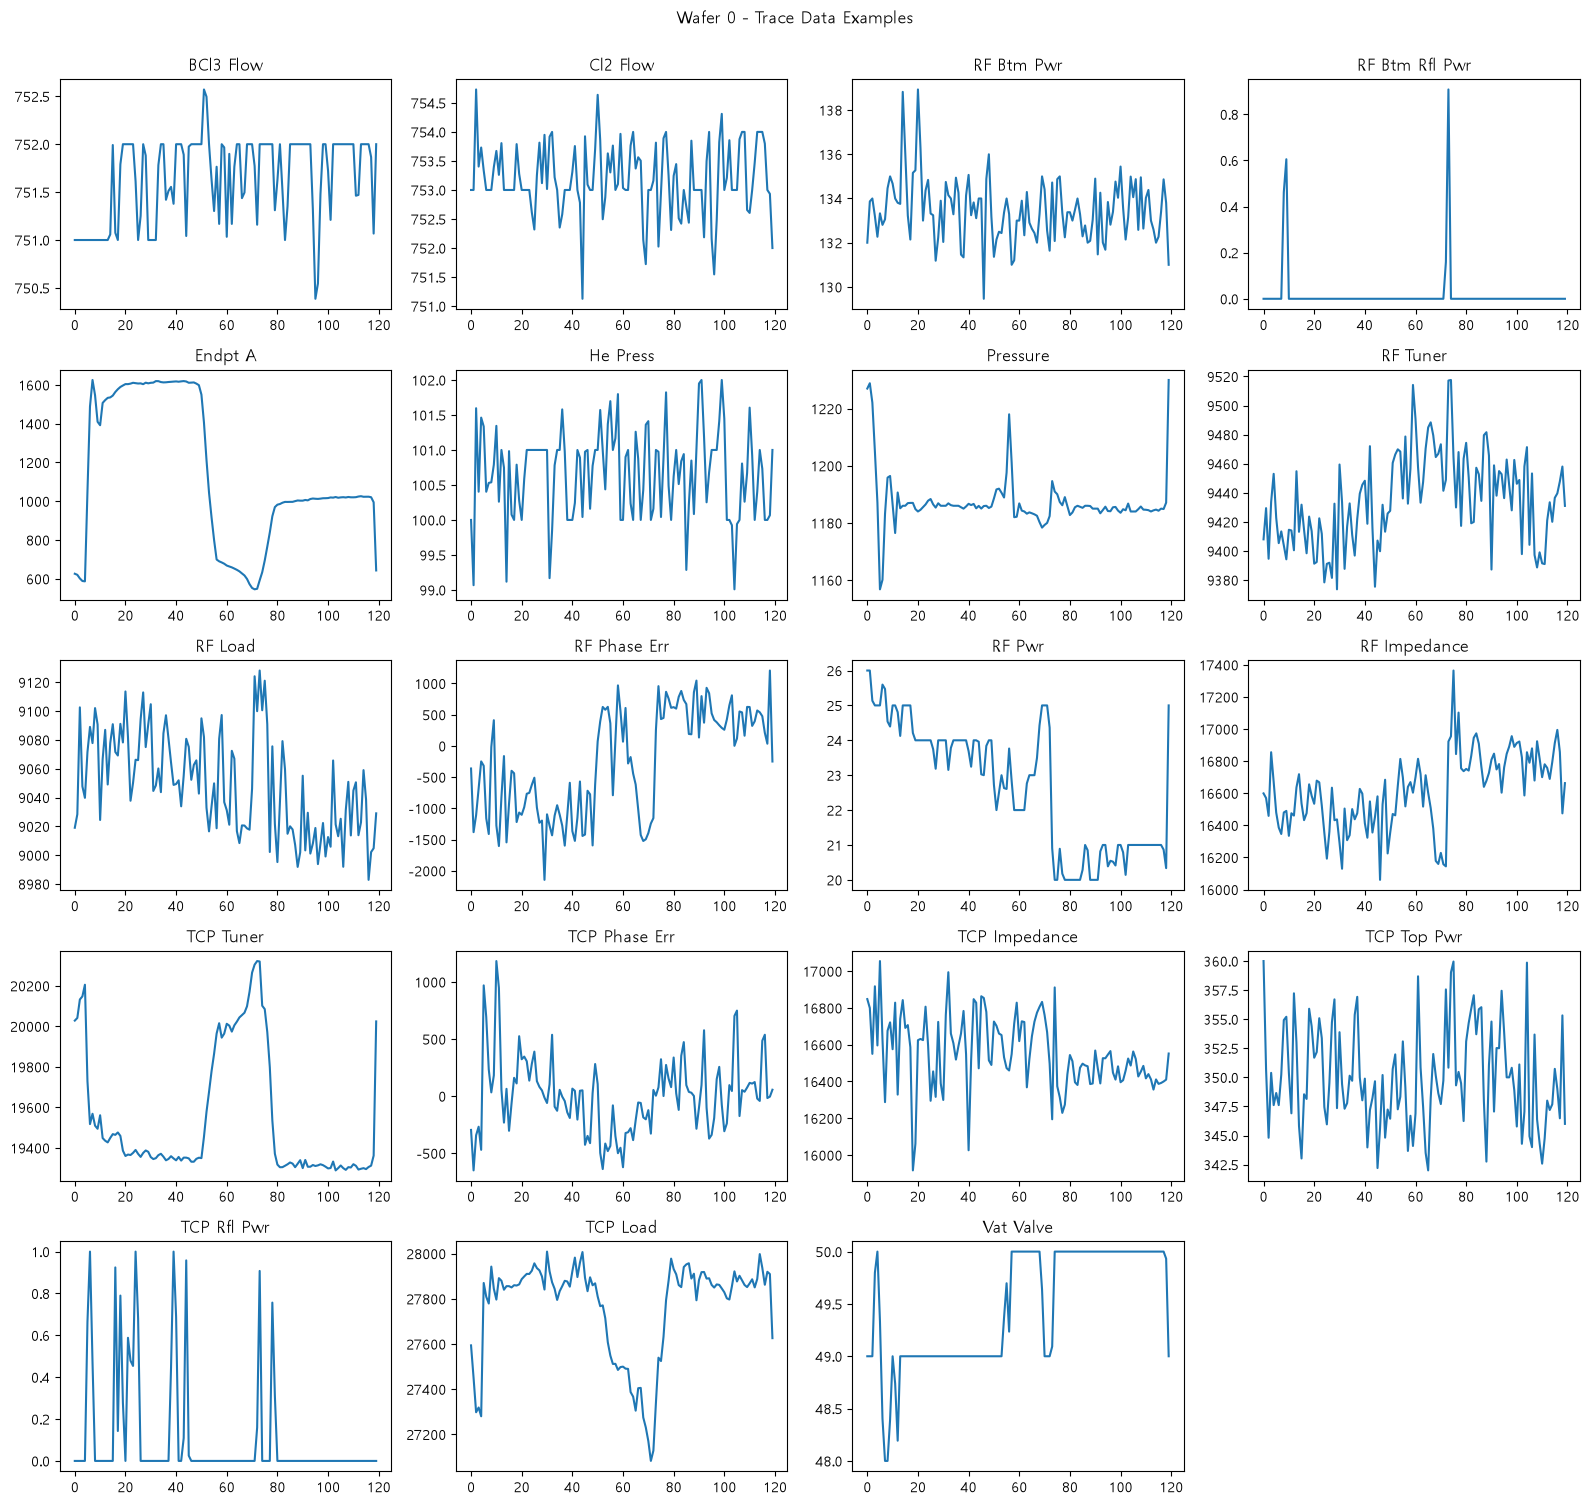

In [8]:
# 0번 웨이퍼의 모든 변수를 시계열로 시각화 (Step Number 제외)
sample = data.loc[0]
cols_to_plot = sample.columns.drop('Step Number')

n_cols = 4  # 한 줄에 그릴 그래프 개수
n_rows = -(-len(cols_to_plot) // n_cols)  # 올림 나눗셈으로 필요한 줄 수 계산

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()  

for i, col in enumerate(cols_to_plot):
    axes[i].plot(sample[col].values)
    axes[i].set_title(col)

for j in range(len(cols_to_plot), len(axes)):
    axes[j].axis('off')  # 남는 빈 칸은 숨김

plt.suptitle('Wafer 0 - Trace Data Examples', y=1.0)
plt.tight_layout()
plt.show()

---

## 2) 데이터 전처리

### 2-1) 불필요 변수 제거 및 스케일링

In [9]:
# Step Number는 공정 단계를 나타내는 변수이므로 분석에서 제외

data.drop("Step Number", axis=1, inplace=True)
print("변수 수:", data.shape[1])

변수 수: 19


In [10]:
# 센서마다 단위/범위가 다름
# 모든 변수를 [0,1]로 맞춰 비교와 요약 통계량 해석을 쉽게 하기 위해 MinMax 사용

scaler = MinMaxScaler()
scaled = scaler.fit_transform(data)
data = pd.DataFrame(scaled, index=data.index, columns=data.columns)
data

,BCl3 Flow,Cl2 Flow,RF Btm Pwr,RF Btm Rfl Pwr,Endpt A,He Press,Pressure,RF Tuner,RF Load,RF Phase Err,RF Pwr,RF Impedance,TCP Tuner,TCP Phase Err,TCP Impedance,TCP Top Pwr,TCP Rfl Pwr,TCP Load,Vat Valve
0,0.511361,0.558719,0.395652,0.000000,0.110639,0.369748,0.608123,0.196640,0.407337,0.584226,0.511071,0.491262,0.673741,0.303314,0.625601,0.948498,0.117241,0.428097,0.418719
0,0.511361,0.558719,0.511072,0.000000,0.108881,0.173981,0.612111,0.244356,0.426067,0.389463,0.511071,0.475377,0.680488,0.224203,0.609187,0.608216,0.117241,0.347737,0.418719
0,0.511361,0.803084,0.519391,0.000000,0.103045,0.704845,0.597597,0.166941,0.575148,0.441400,0.449431,0.414323,0.727484,0.292876,0.524820,0.394237,0.117241,0.262535,0.418719
0,0.511361,0.615658,0.469999,0.000000,0.098897,0.454404,0.561168,0.253813,0.465046,0.523174,0.439856,0.632181,0.735533,0.309597,0.649136,0.597793,0.117241,0.274316,0.485574
0,0.511361,0.661922,0.412289,0.000000,0.098303,0.676626,0.522854,0.296819,0.449049,0.605907,0.439856,0.530532,0.765205,0.264398,0.540313,0.496628,0.117241,0.252597,0.502463
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,0.515734,0.590747,0.375895,0.000000,0.100687,0.694263,0.608123,0.106291,0.140509,0.890995,0.511071,0.317789,0.065995,0.296368,0.495968,0.327956,0.117241,0.878083,0.586207
128,0.522537,0.476868,0.441404,0.000000,0.100172,0.667808,0.608123,0.078312,0.177058,0.907634,0.552364,0.294897,0.085142,0.396483,0.504925,0.607539,0.117241,0.853797,0.586207
128,0.530635,0.526690,0.543306,0.386555,0.099644,0.579625,0.606470,0.161595,0.122218,0.811244,0.554758,0.383547,0.107355,0.485057,0.524888,0.751623,0.117241,0.847535,0.586207
128,0.530635,0.672598,0.581260,0.806723,0.099827,0.539060,0.604674,0.239814,0.047686,0.710199,0.511071,0.478747,0.123333,0.492870,0.536195,0.646779,0.139901,0.836582,0.586207


---

## 3) Trace Data → 머신러닝 입력 데이터로 변환

### 요약 통계량(Summary Statistics) 후보

> 시계열 데이터를 1행으로 요약할 때 사용할 수 있는 **통계량 후보**
>
> | 통계량 | 설명 | 적합한 데이터 특성 |
> |:---:|:---|:---|
> | **Mean** (평균) | 구간의 전반적인 수준 | 안정적인 센서, 전체 경향 파악 |
> | **Std** (표준편차) | 값의 흩어진 정도 | 진동, 불안정한 센서 |
> | **Variance** (분산) | 변동성의 크기 | Std와 유사, 제곱 스케일 |
> | **Min** (최솟값) | 구간 내 최저점 | 하한 이탈 감지 |
> | **Max** (최댓값) | 구간 내 최고점 | 상한 이탈 감지 |
> | **Range** (범위) | Max - Min | 값의 변동 폭 |
> | **Q25** (1사분위) | 하위 25% 지점 | 분포의 하단 특성 |
> | **Q50** (중앙값) | 하위 50% 지점 | 이상치에 강건한 중심값 |
> | **Q75** (3사분위) | 하위 75% 지점 | 분포의 상단 특성 |

### 3-1) 전체 구간 요약 (Simple Summary)

> 각 제품의 **전체 시계열**을 변수별로 요약하여 1행으로 만드는 방법
> - 장점: 구현이 간단
> - 단점: 시간에 따른 변화 패턴 정보가 사라짐

In [11]:
# 예시: 0번 웨이퍼의 변수별 평균
data.loc[0].mean()

BCl3 Flow         0.523757
Cl2 Flow          0.585083
RF Btm Pwr        0.486355
RF Btm Rfl Pwr    0.017787
Endpt A           0.272718
He Press          0.510136
Pressure          0.523068
RF Tuner          0.256533
RF Load           0.467918
RF Phase Err      0.603699
RF Pwr            0.271868
RF Impedance      0.501563
TCP Tuner         0.422124
TCP Phase Err     0.371361
TCP Impedance     0.526252
TCP Top Pwr       0.583803
TCP Rfl Pwr       0.129778
TCP Load          0.524479
Vat Valve         0.458380
dtype: float64

In [12]:
# 전체 웨이퍼에 대해 Mean, Std로 요약
data_summary = []
for wafer_idx in data.index.unique():  # 웨이퍼별로 반복
    temp = data.loc[wafer_idx]  # 해당 웨이퍼의 시점 정보 추출
    temp_summary = []
    for col in temp.columns:  # 변수별로 반복
        temp_summary.append(temp[col].mean())  # 해당 변수의 평균
        temp_summary.append(temp[col].std())   # 해당 변수의 표준편차
    data_summary.append(temp_summary)  # 웨이퍼 하나의 요약 통계를 리스트에 추가

data_summary = np.array(data_summary)  # 전체를 numpy 배열로 변환 (웨이퍼 수 x (변수 수*2))

print("요약 데이터 크기:", data_summary.shape)
print(f"→ {len(data.index.unique())}개 웨이퍼 × ({len(data.columns)}개 변수 × 2개 통계량)")

요약 데이터 크기: (129, 38)
→ 129개 웨이퍼 × (19개 변수 × 2개 통계량)


In [13]:
# 컬럼명 생성 (각 원본 변수마다 Mean, Std 두 개씩)
cols = []
for col in data.columns:
    cols.extend([col + '_Mean', col + '_Std'])  # 예: 'RF Btm Pwr_Mean', 'RF Btm Pwr_Std'

# numpy 배열을 DataFrame으로 변환 + 컬럼명 지정
simple_summary = pd.DataFrame(data_summary, columns=cols)
simple_summary

,BCl3 Flow_Mean,BCl3 Flow_Std,Cl2 Flow_Mean,Cl2 Flow_Std,RF Btm Pwr_Mean,RF Btm Pwr_Std,RF Btm Rfl Pwr_Mean,RF Btm Rfl Pwr_Std,Endpt A_Mean,Endpt A_Std,...,TCP Impedance_Mean,TCP Impedance_Std,TCP Top Pwr_Mean,TCP Top Pwr_Std,TCP Rfl Pwr_Mean,TCP Rfl Pwr_Std,TCP Load_Mean,TCP Load_Std,Vat Valve_Mean,Vat Valve_Std
0,0.523757,0.008694,0.585083,0.086170,0.486355,0.087460,0.017787,0.108112,0.272718,0.119195,...,0.526252,0.066211,0.583803,0.156939,0.129778,0.030836,0.524479,0.121741,0.458380,0.046214
1,0.525246,0.007329,0.578094,0.077257,0.474518,0.073812,0.010014,0.090705,0.278572,0.125736,...,0.522100,0.066667,0.556310,0.143814,0.130369,0.031106,0.530764,0.130548,0.457037,0.045342
2,0.522982,0.007903,0.589235,0.085635,0.470380,0.077469,0.000000,0.000000,0.285295,0.129797,...,0.526595,0.065073,0.543097,0.141925,0.133736,0.035531,0.534498,0.138545,0.457430,0.044085
3,0.524711,0.007350,0.581554,0.081651,0.458877,0.078458,0.000000,0.000000,0.286315,0.132098,...,0.516816,0.067512,0.587066,0.127076,0.134368,0.035763,0.525254,0.125728,0.458075,0.043920
4,0.524918,0.008056,0.578598,0.081402,0.468353,0.060809,0.000000,0.000000,0.289958,0.133271,...,0.520427,0.061924,0.558137,0.165919,0.131732,0.031512,0.533673,0.129399,0.460063,0.044095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,0.526524,0.006913,0.581367,0.074842,0.485240,0.084821,0.000000,0.000000,0.114010,0.066861,...,0.494755,0.064159,0.573907,0.135505,0.138013,0.037801,0.717750,0.155592,0.383861,0.040661
125,0.524627,0.008594,0.607918,0.082623,0.476118,0.074254,0.000000,0.000000,0.109602,0.066323,...,0.510733,0.076942,0.585410,0.156046,0.138900,0.039384,0.712200,0.146260,0.457260,0.043819
126,0.525995,0.008824,0.579498,0.080450,0.478591,0.090028,0.020448,0.131562,0.101489,0.057687,...,0.522362,0.061403,0.572267,0.141153,0.137701,0.037578,0.775177,0.133637,0.653859,0.088332
127,0.524423,0.008035,0.589779,0.075219,0.480371,0.070346,0.032073,0.144075,0.102761,0.066044,...,0.509995,0.063144,0.546312,0.150696,0.131782,0.031609,0.798606,0.154819,0.370109,0.043247


---

### 3-2) 구간별 요약 (Step-based Summary)

> 시계열을 **누적 구간으로 나누어** 각 구간별로 요약하는 방법
>
> 예시: 120개 시점을 6개 누적 구간으로 나누기
> ```
> step_list = [20, 40, 60, 80, 100, -1]
> ```
> | 구간 | 시점 범위 | 설명 |
> |:---:|:---:|:---|
> | Step 0 | 0 ~ 19 | 처음 20개 시점 (공정 초기) |
> | Step 1 | 0 ~ 39 | 처음 40개 시점까지 누적 |
> | Step 2 | 0 ~ 59 | 처음 60개 시점까지 누적 |
> | Step 3 | 0 ~ 79 | 처음 80개 시점까지 누적 |
> | Step 4 | 0 ~ 99 | 처음 100개 시점까지 누적 |
> | Step 5 | 0 ~ 끝 | 전체 시점 (전 구간 누적) |
>
> 매 구간마다 이전 구간을 포함해서 범위가 점점 넓어지는 방식 
> - 공정이 진행될수록 누적된 패턴이 어떻게 변화하는지 포착할 수 있음

In [14]:
step_list = [20, 40, 60, 80, 100, -1]

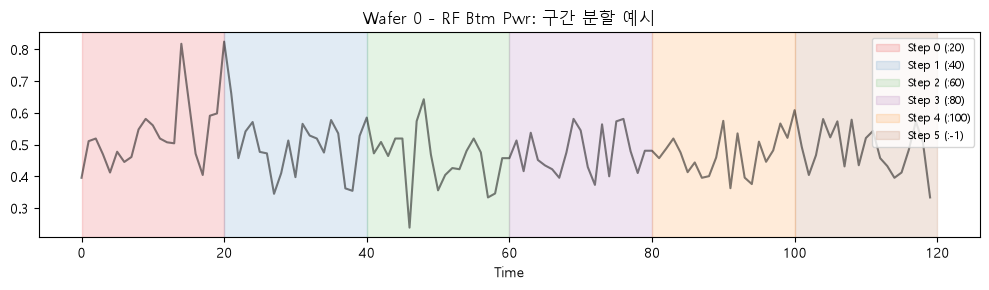

In [15]:
# 구간별 요약 시각화: 0번 웨이퍼의 'RF Btm Pwr' 변수
sample = data.loc[0]['RF Btm Pwr']

plt.figure(figsize=(10, 3))
plt.plot(range(len(sample)), sample.values, color='black', alpha=0.5)
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']
prev = 0
for i, step in enumerate(step_list):
    end = step if step != -1 else len(sample)
    plt.axvspan(prev, end, alpha=0.15, color=colors[i], label=f'Step {i} (:{step})')
    prev = end
plt.title('Wafer 0 - RF Btm Pwr: 구간 분할 예시')
plt.xlabel('Time')
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

In [16]:
# 구간별(누적) Mean, Std 요약
data_summary = []

for wafer_idx in data.index.unique():  # 웨이퍼별로 반복
    temp = data.loc[wafer_idx]  # 해당 웨이퍼의 시점 정보 추출
    temp_summary = []
    for col in temp.columns:  # 변수별로 반복
        for step in step_list:  # 누적 구간별로 반복 (0~step 시점까지)
            segment = temp[col][:step]  # 해당 구간(0부터 step까지)의 데이터 추출
            temp_summary.append(segment.mean())  # 해당 구간의 평균
            temp_summary.append(segment.std())   # 해당 구간의 표준편차
    data_summary.append(temp_summary)  # 웨이퍼 하나의 요약 통계를 리스트에 추가

data_summary = np.array(data_summary)  # 전체를 numpy 배열로 변환 (웨이퍼 수 x (변수 수 * 구간 수 * 2))

print("요약 데이터 크기:", data_summary.shape)
print(f"→ {len(data.index.unique())}개 웨이퍼 × ({len(data.columns)}개 변수 × {len(step_list)}개 구간 × 2개 통계량)")

요약 데이터 크기: (129, 228)
→ 129개 웨이퍼 × (19개 변수 × 6개 구간 × 2개 통계량)


In [17]:
# 컬럼명 생성
cols = []
for col in data.columns:
    for step_num in range(len(step_list)):
        cols.extend([f'{col}_Step{step_num}_Mean', f'{col}_Step{step_num}_Std'])

step_summary = pd.DataFrame(data_summary, columns=cols)
step_summary

,BCl3 Flow_Step0_Mean,BCl3 Flow_Step0_Std,BCl3 Flow_Step1_Mean,BCl3 Flow_Step1_Std,BCl3 Flow_Step2_Mean,BCl3 Flow_Step2_Std,BCl3 Flow_Step3_Mean,BCl3 Flow_Step3_Std,BCl3 Flow_Step4_Mean,BCl3 Flow_Step4_Std,...,Vat Valve_Step1_Mean,Vat Valve_Step1_Std,Vat Valve_Step2_Mean,Vat Valve_Step2_Std,Vat Valve_Step3_Mean,Vat Valve_Step3_Std,Vat Valve_Step4_Mean,Vat Valve_Step4_Std,Vat Valve_Step5_Mean,Vat Valve_Step5_Std
0,0.514171,0.006546,0.518257,0.008290,0.521678,0.009264,0.522723,0.008836,0.522999,0.009010,...,0.414251,0.030215,0.421745,0.032326,0.437456,0.042431,0.450457,0.046040,0.458714,0.046265
1,0.522067,0.008294,0.523654,0.007533,0.524707,0.007389,0.525234,0.007503,0.524809,0.007404,...,0.413881,0.025357,0.419505,0.027042,0.435486,0.039984,0.448881,0.044730,0.457359,0.045396
2,0.516406,0.006926,0.519751,0.008012,0.520790,0.007964,0.522061,0.008073,0.522744,0.008073,...,0.418596,0.025935,0.421839,0.026129,0.436084,0.038157,0.449360,0.043289,0.457756,0.044126
3,0.519630,0.007844,0.522347,0.007636,0.523258,0.007469,0.523997,0.007343,0.525106,0.007122,...,0.418438,0.026445,0.423376,0.027838,0.437069,0.038439,0.450148,0.043246,0.458406,0.043955
4,0.517492,0.007893,0.521257,0.009289,0.523646,0.008709,0.523193,0.008381,0.524665,0.008052,...,0.418455,0.026349,0.425698,0.031000,0.440042,0.040296,0.452526,0.043880,0.460411,0.044116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,0.520990,0.008140,0.524744,0.007581,0.526354,0.006979,0.526343,0.006902,0.526340,0.007060,...,0.348997,0.030392,0.353612,0.033984,0.366432,0.039593,0.376890,0.041143,0.383568,0.040706
125,0.516010,0.007314,0.519901,0.009486,0.522353,0.009399,0.523869,0.008883,0.524751,0.008446,...,0.418526,0.026465,0.423516,0.028084,0.435864,0.037599,0.449184,0.042952,0.457584,0.043860
126,0.516797,0.009776,0.521907,0.010027,0.523983,0.009812,0.525025,0.009428,0.525394,0.009058,...,0.576689,0.059000,0.586582,0.058876,0.608761,0.064567,0.637748,0.081985,0.655835,0.086001
127,0.515062,0.008607,0.520018,0.009273,0.521862,0.009014,0.523163,0.008580,0.524385,0.008210,...,0.339937,0.034586,0.341954,0.031949,0.345804,0.031980,0.360387,0.040931,0.369701,0.043197


---

### 3-3) 다양한 통계량을 활용한 구간별 요약

> **다양한 통계량을 조합**하면 더 풍부한 정보를 머신러닝 모델에 제공할 수 있음

In [18]:
# 사용할 통계량 정의
stat_funcs = {
    'Mean': lambda x: x.mean(),
    'Std': lambda x: x.std(),
    'Min': lambda x: x.min(),
    'Max': lambda x: x.max(),
    'Range': lambda x: x.max() - x.min(),
    'Q25': lambda x: x.quantile(0.25),
    'Q50': lambda x: x.quantile(0.50),
    'Q75': lambda x: x.quantile(0.75),
}

print("사용할 통계량:", list(stat_funcs.keys()))

사용할 통계량: ['Mean', 'Std', 'Min', 'Max', 'Range', 'Q25', 'Q50', 'Q75']


In [19]:
step_list = [20, 40, 60, 80, 100, -1]

data_summary = []
for wafer_idx in data.index.unique():
    temp = data.loc[wafer_idx]
    temp_summary = []
    for col in temp.columns:
        for step in step_list:
            segment = temp[col][:step]
            for func in stat_funcs.values():
                temp_summary.append(func(segment))
    data_summary.append(temp_summary)

data_summary = np.array(data_summary)
print("요약 데이터 크기:", data_summary.shape)
print(f"→ {len(data.index.unique())}개 웨이퍼 × ({len(data.columns)}개 변수 × {len(step_list)}개 구간 × {len(stat_funcs)}개 통계량)")

요약 데이터 크기: (129, 912)
→ 129개 웨이퍼 × (19개 변수 × 6개 구간 × 8개 통계량)


In [20]:
# 컬럼명 생성
cols = []
for col in data.columns:
    for step_num in range(len(step_list)):
        for stat_name in stat_funcs.keys():
            cols.append(f'{col}_Step{step_num}_{stat_name}')

full_summary = pd.DataFrame(data_summary, columns=cols)

print("최종 변수 수:", full_summary.shape[1])
full_summary

최종 변수 수: 912


,BCl3 Flow_Step0_Mean,BCl3 Flow_Step0_Std,BCl3 Flow_Step0_Min,BCl3 Flow_Step0_Max,BCl3 Flow_Step0_Range,BCl3 Flow_Step0_Q25,BCl3 Flow_Step0_Q50,BCl3 Flow_Step0_Q75,BCl3 Flow_Step1_Mean,BCl3 Flow_Step1_Std,...,Vat Valve_Step4_Q50,Vat Valve_Step4_Q75,Vat Valve_Step5_Mean,Vat Valve_Step5_Std,Vat Valve_Step5_Min,Vat Valve_Step5_Max,Vat Valve_Step5_Range,Vat Valve_Step5_Q25,Vat Valve_Step5_Q50,Vat Valve_Step5_Q75
0,0.514171,0.006546,0.511361,0.530635,0.019274,0.511361,0.511361,0.511644,0.518257,0.008290,...,0.418719,0.502463,0.458714,0.046265,0.334975,0.502463,0.167488,0.418719,0.477129,0.502463
1,0.522067,0.008294,0.511361,0.530635,0.019274,0.513386,0.522375,0.530635,0.523654,0.007533,...,0.418719,0.502463,0.457359,0.045396,0.334975,0.502463,0.167488,0.418719,0.464462,0.502463
2,0.516406,0.006926,0.511361,0.530635,0.019274,0.511361,0.511361,0.522982,0.519751,0.008012,...,0.418719,0.502463,0.457756,0.044126,0.334975,0.502463,0.167488,0.418719,0.443350,0.502463
3,0.519630,0.007844,0.511361,0.530635,0.019274,0.511361,0.518245,0.527477,0.522347,0.007636,...,0.418719,0.502463,0.458406,0.043955,0.334975,0.502463,0.167488,0.418719,0.453202,0.502463
4,0.517492,0.007893,0.511361,0.530635,0.019274,0.511361,0.511361,0.523104,0.521257,0.009289,...,0.418719,0.502463,0.460411,0.044116,0.334975,0.502463,0.167488,0.418719,0.486981,0.502463
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,0.520990,0.008140,0.511361,0.530635,0.019274,0.511361,0.521808,0.529056,0.524744,0.007581,...,0.374384,0.418719,0.383568,0.040706,0.334975,0.418719,0.083744,0.334975,0.418719,0.418719
125,0.516010,0.007314,0.511361,0.530635,0.019274,0.511361,0.511361,0.518285,0.519901,0.009486,...,0.418719,0.502463,0.457584,0.043860,0.334975,0.502463,0.167488,0.418719,0.450387,0.502463
126,0.516797,0.009776,0.495150,0.533699,0.038549,0.514424,0.514424,0.522968,0.521907,0.010027,...,0.588670,0.687368,0.655835,0.086001,0.418719,0.753695,0.334975,0.586207,0.669951,0.753695
127,0.515062,0.008607,0.495164,0.530635,0.035471,0.511361,0.512333,0.518488,0.520018,0.009273,...,0.334975,0.418719,0.369701,0.043197,0.251232,0.418719,0.167488,0.334975,0.334975,0.418719


> **참고**
> - 통계량을 많이 사용하면 변수 수가 급격히 늘어남
> - 변수가 너무 많으면 **차원의 저주**가 발생할 수 있으므로, 이후 mRMR, Boruta 등의 **차원 축소** 기법을 적용하는 것이 좋음

---

## 4) Vibe Coding 실습

**[과제 1]** 

지수는 지금까지 모든 변수에 Mean, Std 같은 통계량을 똑같이 적용해서 요약했는데
변수마다 분포 특성이 다르다는 걸 알게 되었습니다.

AI와 상의하여 변수별 분포 특성을 분석하는 코드를 작성하고 변수마다 적합한 통계량을 추천받아 요약해 보세요.

[프롬프트]
위에서 분석한 Trace data에서 변수별 분포 특성을 분석하는 코드를 작성해줘.
그리고 각 변수마다 적합한 통계량을 결정할 방법을 설명해줘. 선생님처럼.

C:\Users\Admin\AppData\Local\Temp\ipykernel_1524\400558187.py:86: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(x.values, vert=True, showfliers=True)


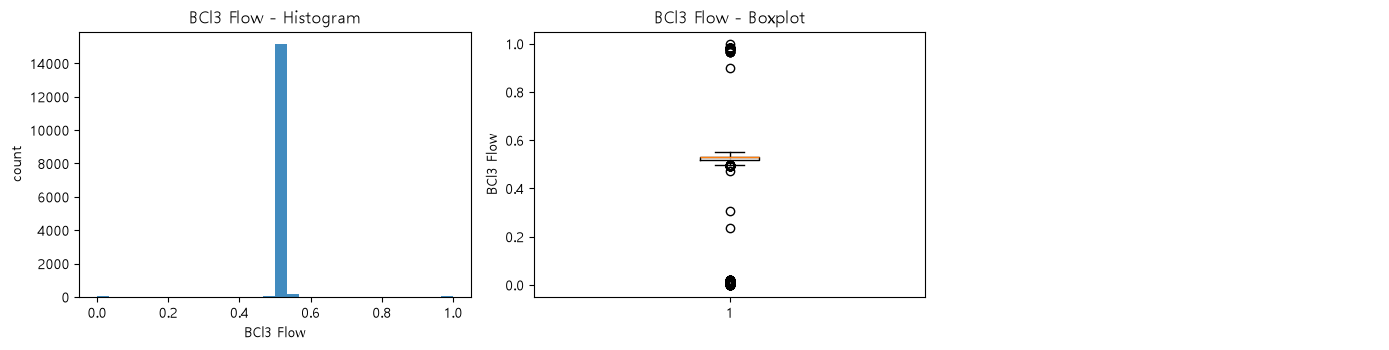

C:\Users\Admin\AppData\Local\Temp\ipykernel_1524\400558187.py:86: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(x.values, vert=True, showfliers=True)


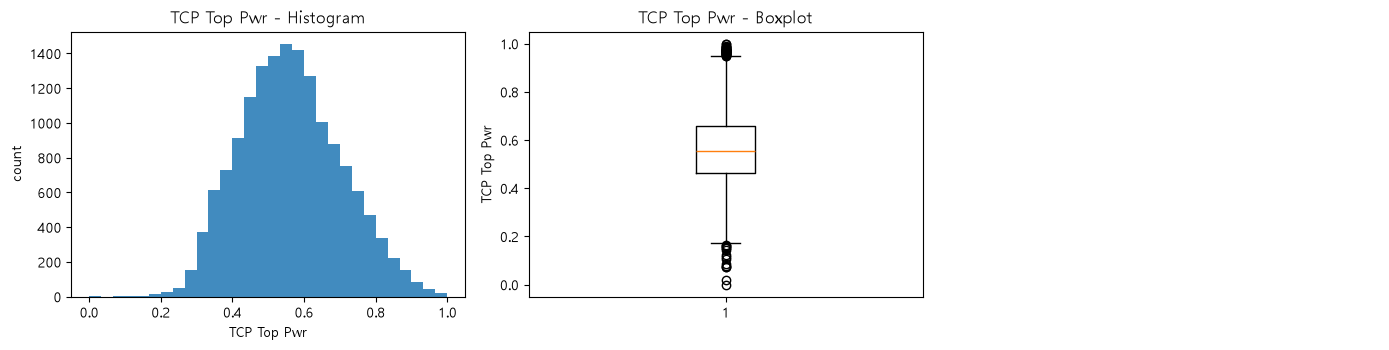

C:\Users\Admin\AppData\Local\Temp\ipykernel_1524\400558187.py:86: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(x.values, vert=True, showfliers=True)


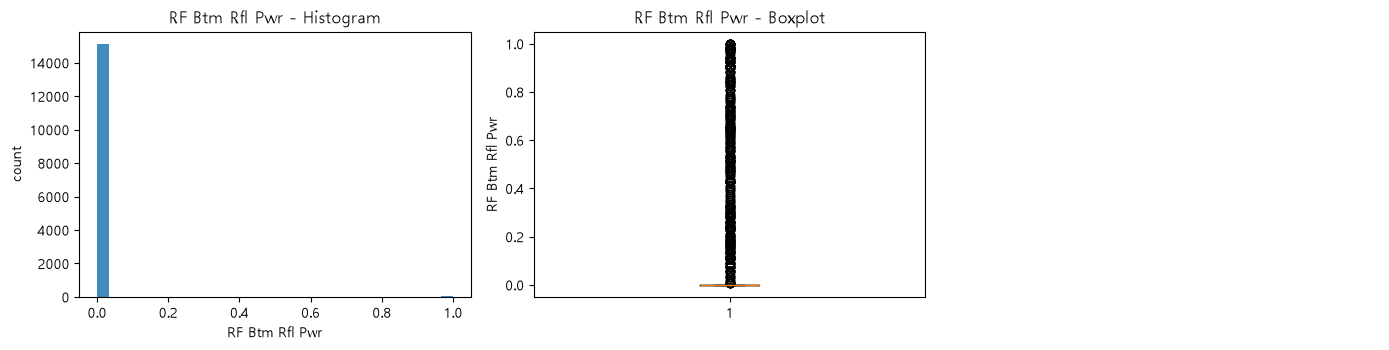

C:\Users\Admin\AppData\Local\Temp\ipykernel_1524\400558187.py:86: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(x.values, vert=True, showfliers=True)


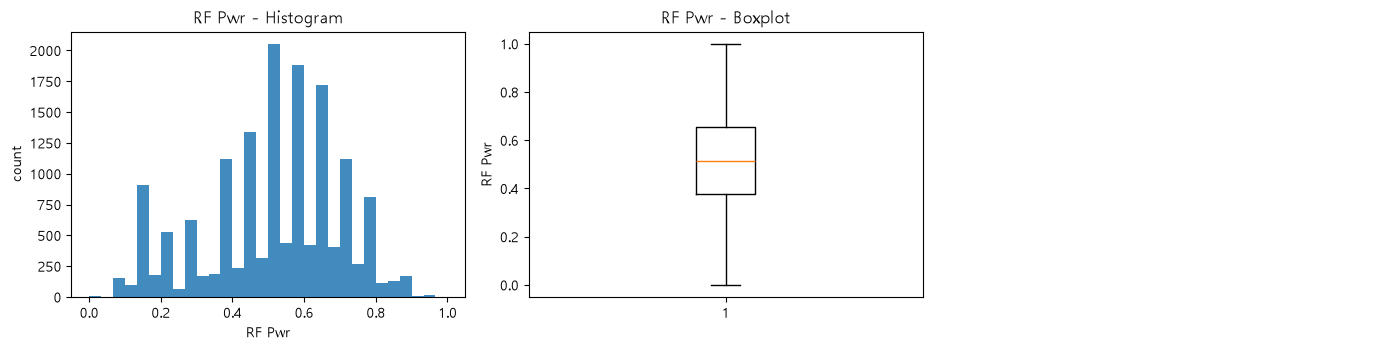

C:\Users\Admin\AppData\Local\Temp\ipykernel_1524\400558187.py:86: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(x.values, vert=True, showfliers=True)


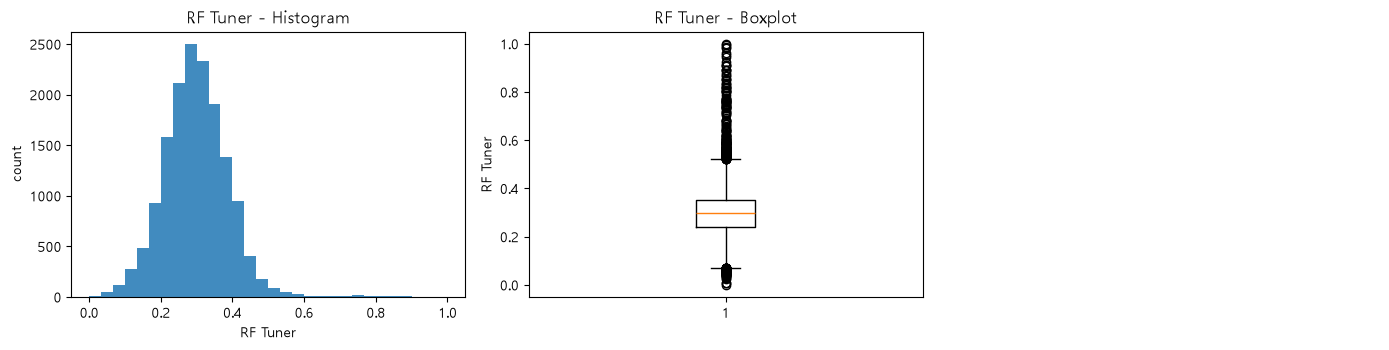

C:\Users\Admin\AppData\Local\Temp\ipykernel_1524\400558187.py:86: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(x.values, vert=True, showfliers=True)


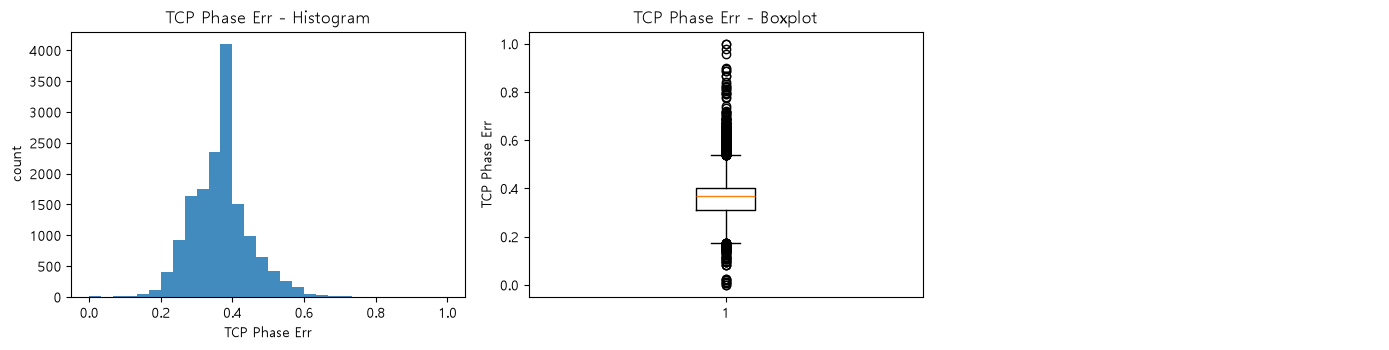


[변수 분포 리포트 상위 10개(이상치 비율 기준)]


,var,n,missing_rate,unique,mean,std,min,p10,median,p90,max,iqr,skew,kurtosis,iqr_outlier_rate
0,TCP Rfl Pwr,15480,0.0,139,0.138906,0.039188,0.0,0.117241,0.117241,0.212808,1.0,0.029557,2.311528,17.238408,0.148320
1,TCP Phase Err,15480,0.0,13984,0.367613,0.082964,0.0,0.267179,0.370509,0.469710,1.0,0.090894,0.628434,2.744281,0.038307
2,TCP Load,15480,0.0,12081,0.601953,0.179189,0.0,0.337023,0.595258,0.848519,1.0,0.184883,-0.375227,-0.104485,0.037016
3,TCP Impedance,15480,0.0,11845,0.519565,0.070743,0.0,0.434344,0.522391,0.601637,1.0,0.080150,-0.436370,3.671529,0.030426
4,Vat Valve,15480,0.0,358,0.482275,0.085252,0.0,0.418719,0.502463,0.586207,1.0,0.083744,0.021618,4.771809,0.026421
5,Cl2 Flow,15480,0.0,687,0.590407,0.086804,0.0,0.474496,0.566429,0.699881,1.0,0.099644,-0.130083,0.811058,0.019832
6,RF Load,15480,0.0,9837,0.384007,0.100110,0.0,0.263702,0.381241,0.503366,1.0,0.128887,0.508567,2.036073,0.017183
7,RF Tuner,15480,0.0,9100,0.298883,0.091621,0.0,0.190859,0.296211,0.407035,1.0,0.112964,0.813404,4.204662,0.016602
8,Pressure,15480,0.0,4551,0.557760,0.057409,0.0,0.514410,0.522989,0.616925,1.0,0.091574,0.806050,5.385636,0.012016
9,RF Btm Pwr,15480,0.0,1220,0.475462,0.080485,0.0,0.381614,0.473118,0.580220,1.0,0.109701,-0.098067,1.412188,0.010078



[변수별 추천 요약 통계량]


,var,skew,iqr_outlier_rate,unique,recommended_stats
0,TCP Rfl Pwr,2.311528,0.148320,139,"median, IQR, p10/p90 (필요시 MAD, clipped mean)"
1,TCP Phase Err,0.628434,0.038307,13984,"median, IQR, p10/p90 (필요시 MAD, clipped mean)"
2,TCP Load,-0.375227,0.037016,12081,"median, IQR, p10/p90 (필요시 MAD, clipped mean)"
3,TCP Impedance,-0.436370,0.030426,11845,"median, IQR, p10/p90 (필요시 MAD, clipped mean)"
4,Vat Valve,0.021618,0.026421,358,"median, IQR, p10/p90 (필요시 MAD, clipped mean)"
5,Cl2 Flow,-0.130083,0.019832,687,"mean, std + p10/p90 (또는 trimmed mean)"
6,RF Load,0.508567,0.017183,9837,"mean, std + p10/p90 (또는 trimmed mean)"
7,RF Tuner,0.813404,0.016602,9100,"mean, std + p10/p90 (또는 trimmed mean)"
8,Pressure,0.806050,0.012016,4551,"mean, std + p10/p90 (또는 trimmed mean)"
9,RF Btm Pwr,-0.098067,0.010078,1220,"mean, std + p10/p90 (또는 trimmed mean)"


In [21]:
# 변수별 분포 특성 분석 + 통계량 추천
# - Trace Data(웨이퍼×시간포인트)에서 '각 변수'의 분포를 먼저 이해하고
# - 그 분포 특성(왜도/이상치 등)에 따라 요약 통계량을 선택하는 예시 코드

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _iqr_outlier_rate(x: pd.Series) -> float:
    x = x.dropna()
    if len(x) < 8:
        return np.nan
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return float(((x < lo) | (x > hi)).mean())


def analyze_variable_distributions(
    df: pd.DataFrame,
    cols=None,
    step_col: str = "Step Number",
    sample_plots: int = 6,
    random_state: int = 42,
) -> pd.DataFrame:
    """각 변수의 분포 특성 요약 리포트(DataFrame)를 생성하고, 일부 변수는 시각화까지 출력."""

    if cols is None:
        cols = df.select_dtypes(include=["number"]).columns.tolist()

    # step 번호는 분포 분석 대상에서 제외(범주형 성격)
    cols = [c for c in cols if c != step_col]

    rows = []
    for c in cols:
        x = df[c]
        x_nonan = x.dropna()
        if len(x_nonan) == 0:
            continue

        q1, q3 = x_nonan.quantile(0.25), x_nonan.quantile(0.75)
        iqr = q3 - q1

        rows.append(
            {
                "var": c,
                "n": int(x_nonan.shape[0]),
                "missing_rate": float(x.isna().mean()),
                "unique": int(x_nonan.nunique()),
                "mean": float(x_nonan.mean()),
                "std": float(x_nonan.std(ddof=1)),
                "min": float(x_nonan.min()),
                "p10": float(x_nonan.quantile(0.10)),
                "median": float(x_nonan.median()),
                "p90": float(x_nonan.quantile(0.90)),
                "max": float(x_nonan.max()),
                "iqr": float(iqr),
                "skew": float(x_nonan.skew()),
                "kurtosis": float(x_nonan.kurtosis()),
                "iqr_outlier_rate": _iqr_outlier_rate(x_nonan),
            }
        )

    report = pd.DataFrame(rows).sort_values("iqr_outlier_rate", ascending=False).reset_index(drop=True)

    # ---- 분포 시각화(샘플 변수) ----
    if sample_plots and len(report) > 0:
        rng = np.random.default_rng(random_state)
        plot_vars = report["var"].tolist()
        plot_vars = rng.choice(plot_vars, size=min(sample_plots, len(plot_vars)), replace=False)

        for c in plot_vars:
            x = df[c].dropna()
            fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

            # 1) Histogram
            axes[0].hist(x, bins=30, alpha=0.85)
            axes[0].set_title(f"{c} - Histogram")
            axes[0].set_xlabel(c)
            axes[0].set_ylabel("count")

            # 2) Boxplot
            axes[1].boxplot(x.values, vert=True, showfliers=True)
            axes[1].set_title(f"{c} - Boxplot")
            axes[1].set_ylabel(c)

            # 3) Step별 분포(가능한 경우)
            if step_col in df.columns:
                tmp = df[[step_col, c]].dropna()
                # step이 너무 많으면 상위 몇 개만
                step_vals = sorted(tmp[step_col].unique().tolist())
                step_vals = step_vals[:10]
                data_by_step = [tmp.loc[tmp[step_col] == s, c].values for s in step_vals]
                axes[2].boxplot(data_by_step, labels=[str(s) for s in step_vals], showfliers=False)
                axes[2].set_title(f"{c} - By {step_col} (Top10)")
                axes[2].set_xlabel(step_col)
                axes[2].tick_params(axis="x", rotation=45)
            else:
                axes[2].axis("off")

            plt.tight_layout()
            plt.show()

    return report


def recommend_summary_stats(report: pd.DataFrame) -> pd.DataFrame:
    """분포 특성(왜도/이상치)을 기준으로 변수별 추천 요약 통계량을 제안."""

    def _recommend_row(r):
        # 경험적 기준(실무에서는 공정 의미/품질지표/사양과 함께 조정)
        skew = abs(r["skew"])
        out = r["iqr_outlier_rate"]
        uniq = r["unique"]

        # 거의 상수면 의미 없음
        if uniq <= 2:
            return "(거의 상수) 제외/또는 step별 유지 여부만 확인"

        # 이상치가 많거나 심하게 비대칭이면 robust 통계량
        if (not np.isnan(out) and out >= 0.02) or skew >= 1.0:
            return "median, IQR, p10/p90 (필요시 MAD, clipped mean)"

        # 약간의 비대칭/이상치 → mean/std + quantile 같이
        if (not np.isnan(out) and out >= 0.01) or skew >= 0.5:
            return "mean, std + p10/p90 (또는 trimmed mean)"

        # 비교적 대칭/이상치 적음
        return "mean, std (필요시 min/max)"

    out = report.copy()
    out["recommended_stats"] = out.apply(_recommend_row, axis=1)
    return out[["var", "skew", "iqr_outlier_rate", "unique", "recommended_stats"]]


# ===== 실행 예시 =====
# 위에서 전처리/스케일링된 Trace Data가 `data`라는 변수명으로 있다고 가정
# (현재 노트북 흐름상 data는 MinMaxScaler 적용된 DataFrame)

report = analyze_variable_distributions(data, sample_plots=6)
print("\n[변수 분포 리포트 상위 10개(이상치 비율 기준)]")
display(report.head(10))

reco = recommend_summary_stats(report)
print("\n[변수별 추천 요약 통계량]")
display(reco.head(20))

# 필요하면 전체를 파일로 저장
# report.to_csv('trace_distribution_report.csv', index=False, encoding='utf-8-sig')
# reco.to_csv('trace_recommend_stats.csv', index=False, encoding='utf-8-sig')


### 추가해둔 코드가 하는 일 (Trace 변수별 분포 분석)

노트북 마지막 빈 코드셀(맨 아래)에, **`data`(Trace Data)** 를 대상으로:

- **변수별 분포 요약 리포트** 생성: `n`, `missing_rate`, `unique`, `mean/std`, `median/IQR`, `skew/kurtosis`, `IQR 기반 이상치 비율`
- **샘플 변수 몇 개 자동 시각화**:
  - 히스토그램
  - 박스플롯
  - (가능하면) `Step Number`별 박스플롯
- 위 분포 지표를 기반으로 **변수별 추천 요약 통계량**(`mean/std` vs `median/IQR/quantile`)을 자동으로 제안

을 한 번에 수행합니다.

---

### 각 변수마다 “적합한 통계량”을 결정하는 방법 (선생님식 설명)

Trace 데이터를 1행으로 요약할 때 핵심은 “**그 변수의 분포가 어떤 위험을 갖는가**”입니다. 아래처럼 판단하면 됩니다.

- **분포가 대칭이고(outlier 적음)**  
  - **상황**: 왜도 \(|skew|\)가 작고, 이상치 비율이 낮음  
  - **추천 통계량**: **`mean`, `std`**  
  - **이유**: 평균/표준편차가 대표값·변동성을 잘 설명함

- **분포가 비대칭이거나(outlier 많음)**  
  - **상황**: 왜도 \(|skew|\)가 크거나, IQR 기반 이상치 비율이 큼  
  - **추천 통계량**: **`median`, `IQR`, `p10/p90` (필요시 MAD, trimmed mean)**  
  - **이유**: 평균은 이상치에 쉽게 끌려가서 “대표값” 역할을 못 함 → **강건(robust) 통계량**이 안전

- **거의 상수(변화가 거의 없음)**  
  - **상황**: `unique`가 매우 작음(예: 1~2)  
  - **추천**: **제외 후보** 또는 **step별 유지 여부만 점검**  
  - **이유**: 모델에 정보량이 거의 없음(단, 특정 step setpoint라면 의미가 있을 수 있어 step별로 확인)

- **Trace 특성(시간/step 구조)** 때문에 추가로 중요한 것  
  - 같은 변수라도 전체 분포보다 **Step별 분포가 더 중요**할 수 있습니다.  
  - 그래서 “전체 요약 통계량”만 고르지 말고:
    - **step별 mean/std(또는 median/IQR)**  
    - **구간별 변화량(Δ), trend(기울기), 안정화 구간 평균**  
    같은 **동특성 요약**을 함께 고려하는 게 실무에선 더 강력합니다.

원하면, 위 추천 결과(`reco`)를 바탕으로 **변수별로 다른 통계량을 적용해서 `full_summary`를 다시 만드는 코드**까지 이어서 만들어 드릴게요.

**`p10`, `p90`은 “처음/마지막 구간(step)”이 아니라, 분포의 분위수(Percentile)** 입니다.

- **`p10` (10th percentile, 10% 분위수)**: 데이터를 작은 값부터 정렬했을 때 **아래 10% 지점의 값**
- **`p90` (90th percentile, 90% 분위수)**: 정렬했을 때 **아래 90% 지점의 값** (= 위쪽 10%가 시작되는 경계)

예를 들어 값이 100개면:
- `p10`은 대략 **10번째쯤** 값
- `p90`은 대략 **90번째쯤** 값

### 왜 쓰나?
- **이상치(max/min)** 처럼 극단값 하나에 휘둘리지 않으면서도
- 분포의 **낮은 쪽/높은 쪽(꼬리)** 를 요약할 수 있어서,
분포가 치우치거나 스파이크가 있는 공정 변수에 자주 씁니다.

### “처음/마지막 구간”을 따로 떼는 건 뭐라고 부르나?
그건 **분위수(p10/p90)** 가 아니라 **구간(step/time window) 요약**이고, 예를 들면:
- `초기구간 평균`, `후기구간 평균`
- `Step4 평균`, `Step5 p90`
- `초기→후기 변화량(Δ)`

같은 형태로 따로 계산합니다.